# Notebook 01: Data Collection - Clinical Trial Failure Prediction for Cancer

## 1. Overview: 

Phần này thu thập dữ liệu thô từ `API` `ClinicalTrials.gov` ở dạng `JSONL` để giữ nguyên cấu trúc JSON lồng nhau (nested) của từng trial, tránh mất thông tin trước khi flatten và trích xuất đặc trưng.

### Tại sao cần thu thập JSON thô?

- Mỗi thử nghiệm từ API là JSON lồng nhau.

- Lưu raw JSON giúp bảo toàn đầy đủ chi tiết cho các bước chuyển đổi/xử lý sau.

### Output và file hệ thống

- collect_raw_jsonl(cfg) → ghi:

    - Raw JSONL: data/raw/ctgov_raw.jsonl

    - Log: data/raw/logs/ctgov_collect.log

- flatten_raw_jsonl_to_csv(raw_path) → đọc JSONL và xuất CSV đã làm phẳng:

    - data/processed/ctgov_flat_{raw_filename_stem}.csv

### Các bước thực hiện

1. `api_smoke_test(cfg)` để kiểm tra kết nối/tham số và xác nhận có dữ liệu.

2. `collect_raw_jsonl(cfg)` tải toàn bộ hồ sơ theo cfg.query_term ("cancer") → trả `(raw_path, log_path)`.

3. `flatten_raw_jsonl_to_csv(raw_path)` để chuyển `JSONL → CSV` phục vụ phân tích/tiền xử lý.


## 2. Environment Setup

### 2.1 Setup and import library: 

In [1]:
import sys 
import json
import importlib 
import numpy as np
import pandas as pd
from pathlib import Path 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

### 2.2. Determine the project root directory 

In [2]:
project_root = Path.cwd().parent
project_root 

PosixPath('/home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction')

### 2.3. Add Project Root 

In [3]:
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
sys.path[0]

'/home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction'

### 2.4. Reload module custom

In [4]:
for mod in ['src.utils.config', 'src.data.data_loader']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

print('Reload done')

Reload done


### 2.5. Setup for Project

In [5]:
from src.utils.config import CollectConfig
from src.data.data_loader import (
    api_smoke_test,
    collect_raw_jsonl,
    flatten_raw_jsonl_to_csv,
)
from src.data.data_loader import raw_quality_report

print("Modules imported successfully!")
print(f"Project root: {project_root}")

Modules imported successfully!
Project root: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction


/home/lang-phu-quy/miniconda3/envs/jupyter_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.6 Configuration Setup

In [6]:
# Goal: reduce irrelevant studies at query time while keeping raw snapshots for reproducibility
cfg = CollectConfig(
    query_term='(cancer OR neoplasm OR carcinoma OR tumor OR malignan*)',
    # These are "intent filters" (logged in metadata). If your query engine supports them in query.term,
    # the loader will encode them; otherwise, you still filter again in preprocessing.
    study_type_filter="INTERVENTIONAL",
    # IMPORTANT: Loại bỏ "PHASE2/PHASE3" vì API không hỗ trợ (gây lỗi 400)
    phase_filter=["PHASE2", "PHASE3"],  # Chỉ dùng PHASE2 và PHASE3 riêng lẻ
    # Optional: only fetch labeled outcomes for supervised learning
    overall_status_filter=["COMPLETED", "TERMINATED", "WITHDRAWN"],
    max_studies=50000,
    page_size=1000,
    sleep_s=0.3,
    timeout_s=30,
    max_retries=5,
    retry_delay_s=2.0,
    max_retry_delay_s=30.0,
    retry_jitter_s=0.2,
    prediction_time="t0 = StartDate",
    label_definition="Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}",
)

### 2.7. Configuration Validation & Display

In [7]:
print("="*80)
print("DATA COLLECTION CONFIGURATION")
print("="*80)
print(f"\nQUERY PARAMETERS:")
print(f"  Query Term:     {cfg.query_term}")
print(f"  Study Type:     {cfg.study_type_filter}")
print(f"  Phases:         {', '.join(cfg.phase_filter) if cfg.phase_filter else 'All'}")
print(f"  Status Filter:  {', '.join(cfg.overall_status_filter) if cfg.overall_status_filter else 'All'}")

print(f"\nCOLLECTION LIMITS:")
print(f"  Max Studies:    {cfg.max_studies:,}")
print(f"  Page Size:      {cfg.page_size:,}")

print(f"\nAPI SETTINGS:")
print(f"  Sleep Time:     {cfg.sleep_s}s")
print(f"  Timeout:        {cfg.timeout_s}s")
print(f"  Max Retries:    {cfg.max_retries}")
print(f"  Retry Delay:    {cfg.retry_delay_s}s - {cfg.max_retry_delay_s}s")
print(f"  Retry Jitter:   ±{cfg.retry_jitter_s}s")

print(f"\nPREDICTION TASK:")
print(f"  Timepoint:      {cfg.prediction_time}")
print(f"  Label:          {cfg.label_definition}")

print("\n" + "="*80)
print("Configuration validated and ready for collection")
print("="*80)

DATA COLLECTION CONFIGURATION

QUERY PARAMETERS:
  Query Term:     (cancer OR neoplasm OR carcinoma OR tumor OR malignan*)
  Study Type:     INTERVENTIONAL
  Phases:         PHASE2, PHASE3
  Status Filter:  COMPLETED, TERMINATED, WITHDRAWN

COLLECTION LIMITS:
  Max Studies:    50,000
  Page Size:      1,000

API SETTINGS:
  Sleep Time:     0.3s
  Timeout:        30s
  Max Retries:    5
  Retry Delay:    2.0s - 30.0s
  Retry Jitter:   ±0.2s

PREDICTION TASK:
  Timepoint:      t0 = StartDate
  Label:          Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}

Configuration validated and ready for collection


## 3. Data Collection Pipeline

### 3.1. API Connectivity Test (Smoke Test)

In [8]:
# Perform a smoke test of the ClinicalTrials.gov API
# This verifies connectivity and returns basic information about available data
ok, info = api_smoke_test(cfg)
ok, info

[2025-12-12 20:35:54,440] INFO - Running API smoke test...
[2025-12-12 20:35:55,422] INFO - ✅ Smoke test passed: 5 studies found


(True,
 {'status_code': 200,
  'endpoint': 'https://clinicaltrials.gov/api/v2/studies',
  'params': {'query.term': '((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND (AREA[OverallStatus]COMPLETED OR AREA[OverallStatus]TERMINATED OR AREA[OverallStatus]WITHDRAWN)',
   'pageSize': 5},
  'has_studies_key': True,
  'studies_len': 5,
  'has_nextPageToken': True,
  'top_keys': ['studies', 'nextPageToken']})

### 3.2. Smoke Test Results Analysis

In [9]:
if ok:
    print("API CONNECTIVITY TEST: PASSED")
    print("="*80)
    print(f"Available Studies: {info.get('studies_len', 0):,}")
    print(f"API Endpoint: {info.get('endpoint', 'N/A')}")
    print(f"⏱Response Time: {info.get('response_time_ms', 0):.0f}ms")
    print("="*80)
    print("\nReady to proceed with full data collection")
else:
    print("API CONNECTIVITY TEST: FAILED")
    print("="*80)
    print(f"Error: {info.get('error', 'Unknown error')}")
    print("="*80)

API CONNECTIVITY TEST: PASSED
Available Studies: 5
API Endpoint: https://clinicaltrials.gov/api/v2/studies
⏱Response Time: 0ms

Ready to proceed with full data collection


### 3.3. Full Data Collection

**Process**:
1.Gọi API ClinicalTrials.gov theo các bộ lọc đã cấu hình

2. Phân trang kết quả (1000 bản ghi/trang)

3. Lưu dữ liệu JSON thô vào file JSONL

4. Tạo log và metadata cho lần thu thập

5. Tính checksum để kiểm tra toàn vẹn dữ liệu

**Expected Output**:
- `data/raw/ctgov_raw_cancer_*.jsonl` - Raw trial records
- `data/raw/ctgov_metadata_*.json` - Collection metadata
- `data/raw/logs/ctgov_collect_*.log` - Execution log

In [10]:
raw_path, log_path = collect_raw_jsonl(cfg)

[2025-12-12 20:35:55,444] INFO - Starting data collection from ClinicalTrials.gov API
[2025-12-12 20:35:55,452] INFO - Output files:
[2025-12-12 20:35:55,455] INFO -   Raw JSONL: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
[2025-12-12 20:35:55,456] INFO -   Log: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/logs/ctgov_collect.log
[2025-12-12 20:35:55,458] INFO -   Metadata: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_metadata.json


[2025-12-12 20:35:55,471] INFO - Starting API collection with query: ((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (ARE...


[2025-12-12 20:42:27,144] INFO - Collection complete: 30593 studies collected
[2025-12-12 20:42:27,145] INFO -    SHA256: 0f122fcbf63d287e...


### 3.4. Report quality crawl: 

In [11]:
raw_path = Path(raw_path)
meta_candidates = sorted(raw_path.parent.glob(f"ctgov_metadata_*{raw_path.stem.split('_')[-1]}*.json"))
meta_path = meta_candidates[-1] if meta_candidates else None

print("Raw JSONL:", raw_path)
print("Metadata:", meta_path)

if meta_path and meta_path.exists():
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    for k in ["run_started_at","run_finished_at","endpoint","params","total_raw_records","raw_sha256","git_commit",
              "prediction_time","label_definition"]:
        print(f"{k}: {meta.get(k)}")

qa = raw_quality_report(raw_path, max_lines=5000)  
qa

[2025-12-12 20:42:27,151] INFO - Generating quality report for ctgov_raw.jsonl...


Raw JSONL: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
Metadata: None


[2025-12-12 20:42:28,428] INFO - Quality Report Summary:
[2025-12-12 20:42:28,428] INFO -   Lines analyzed: 5000
[2025-12-12 20:42:28,429] INFO -   Parse errors: 0 (0.00%)
[2025-12-12 20:42:28,429] INFO -   Complete nct_id: 0.0% missing
[2025-12-12 20:42:28,429] INFO -   Complete overall_status: 0.0% missing
[2025-12-12 20:42:28,429] INFO -   Complete start_date: 1.3% missing
[2025-12-12 20:42:28,430] INFO -   Complete study_type: 0.0% missing


{'raw_path': '/home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl',
 'total_lines_read': 5000,
 'json_parse_errors': 0,
 'parse_error_rate': 0.0,
 'missing_critical_counts': {'nct_id': 0,
  'overall_status': 0,
  'start_date': 64,
  'study_type': 0},
 'missing_critical_rates': {'nct_id': 0.0,
  'overall_status': 0.0,
  'start_date': 0.0128,
  'study_type': 0.0},
 'top_level_keys_coverage': {'protocolSection': 5000,
  'derivedSection': 5000,
  'hasResults': 5000,
  'resultsSection': 2210,
  'documentSection': 1066,
  'annotationSection': 68}}

### 3.5. Collection Logs Review

We examine the logs from the data collection process to understand what was collected and identify any issues that occurred during the download.

In [12]:
# Display the first 1200 characters of the collection log
# This shows the progress and any errors encountered during data collection
print(log_path.read_text(encoding="utf-8")[:1200])

{"event": "run_start", "run_started_at": "2025-12-12T13:35:55Z", "run_tag": "20251212_203555", "endpoint": "https://clinicaltrials.gov/api/v2/studies", "params": {"query.term": "((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND (AREA[OverallStatus]COMPLETED OR AREA[OverallStatus]TERMINATED OR AREA[OverallStatus]WITHDRAWN)", "pageSize": 1000}, "timeout_s": 30, "max_retries": 5, "retry_delay_s": 2.0, "sleep_s": 0.3, "max_studies": 50000, "git_commit": "cda0ad9bff5ca6693eb03364e78d05f43bf4f7a4", "prediction_time": "t0 = StartDate", "label_definition": "Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}", "raw_path": "/home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl", "log_path": "/home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/logs/ctgov_colle

## 4. Data Flattening and CSV Conversion

In [13]:
# Define the path to the processed CSV file containing flattened clinical trial data
# This file contains all the cancer trial information in a tabular format ready for analysis
csv_path = flatten_raw_jsonl_to_csv(raw_path) 

[2025-12-12 20:42:28,448] INFO - Flattening ctgov_raw.jsonl to CSV...
[2025-12-12 20:42:37,091] INFO - ✅ Flattening complete: ctgov_flat.csv
[2025-12-12 20:42:37,092] INFO -    Total lines: 30593
[2025-12-12 20:42:37,093] INFO -    Kept records: 30593
[2025-12-12 20:42:37,093] INFO -    Parse errors: 0


### 4.1 Data Loading & Exploratory Analysis

In [14]:
print("DATASET OVERVIEW")
print(f"File Path: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Dimensions: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Data Types: {df.dtypes.value_counts().to_dict()}")

DATASET OVERVIEW
File Path: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/ctgov_flat.csv
Dimensions: 30,593 rows × 23 columns
Memory Usage: 35.86 MB
Data Types: {dtype('O'): 18, dtype('int64'): 3, dtype('float64'): 1, dtype('bool'): 1}


### 4.2. Load Processed Dataset

In [15]:
df.shape

(30593, 23)

In [16]:
df.head(3)

,nct_id,brief_title,overall_status,start_date,completion_date,study_type,phases,allocation,intervention_model,primary_purpose,...,lead_sponsor_name,lead_sponsor_class,has_dmc,conditions,num_conditions,intervention_types,intervention_names,num_interventions,num_arms,has_results
0,NCT00109928,S0350 Combination Chemotherapy in Treating Pat...,COMPLETED,2005-09-01,2014-04-01,INTERVENTIONAL,PHASE2,NaN,SINGLE_GROUP,TREATMENT,...,SWOG Cancer Research Network,NETWORK,False,Lymphoma,1,DRUG,cisplatin|etoposide|gemcitabine|methylpredniso...,4,1,True
1,NCT00066365,Inhaled Sargramostim in Treating Patients With...,COMPLETED,2004-07-01,2013-12-01,INTERVENTIONAL,PHASE2,NON_RANDOMIZED,PARALLEL,TREATMENT,...,Children's Oncology Group,NETWORK,True,Metastatic Cancer|Sarcoma,2,BIOLOGICAL|PROCEDURE,sargramostim|conventional surgery,2,2,True
2,NCT03908567,AM-125 in the Treatment of Acute Peripheral Ve...,COMPLETED,2019-07-18,2022-03-28,INTERVENTIONAL,PHASE2,RANDOMIZED,PARALLEL,TREATMENT,...,Auris Medical AG,INDUSTRY,True,Vestibular Vertigo,1,DRUG|OTHER,Intranasal Drug|Oral Tablet|Intranasal Placebo,3,5,False


### 4.3. Data Structure Analysis

In [17]:
# Examine the data types of each column in the dataset
df.dtypes

nct_id                 object
brief_title            object
overall_status         object
start_date             object
completion_date        object
study_type             object
phases                 object
allocation             object
intervention_model     object
primary_purpose        object
masking                object
enrollment_count      float64
enrollment_type        object
lead_sponsor_name      object
lead_sponsor_class     object
has_dmc                object
conditions             object
num_conditions          int64
intervention_types     object
intervention_names     object
num_interventions       int64
num_arms                int64
has_results              bool
dtype: object

## 5. Validation & Quality Check

### 5.1 Missing Data Analysis

In [18]:
# Calculate the percentage of missing values for each column
df.isna().mean().sort_values(ascending=False)

allocation            0.419802
has_dmc               0.220475
intervention_model    0.063642
enrollment_type       0.062531
completion_date       0.054293
masking               0.045337
enrollment_count      0.031347
start_date            0.010198
primary_purpose       0.004674
num_arms              0.000000
num_interventions     0.000000
intervention_names    0.000000
intervention_types    0.000000
num_conditions        0.000000
conditions            0.000000
nct_id                0.000000
lead_sponsor_class    0.000000
lead_sponsor_name     0.000000
brief_title           0.000000
phases                0.000000
study_type            0.000000
overall_status        0.000000
has_results           0.000000
dtype: float64

### 5.2. Check for duplicate NCT ID

In [19]:
duplicate_ids = df['nct_id'].duplicated().sum()
unique_ids = df['nct_id'].nunique()
total_records = len(df)

print("="*60)
print("DUPLICATE CHECK")
print("="*60)
print(f"Total records: {total_records:,}")
print(f"Unique NCT IDs: {unique_ids:,}")
print(f"Duplicate records: {duplicate_ids}")
print(f"Data Uniqueness: {(unique_ids/total_records)*100:.2f}%")

DUPLICATE CHECK
Total records: 30,593
Unique NCT IDs: 30,593
Duplicate records: 0
Data Uniqueness: 100.00%


### 5.3. Data quality assesment:

In [20]:
# 1. Completeness: Percentage of non-missing values
completeness_score = (1 - df.isna().mean().mean()) * 100

# 2. Uniqueness: Check if primary key is unique
uniqueness_score = (df['nct_id'].nunique() / len(df)) * 100

# 3. Validity: Check for logical inconsistencies
validity_score = 100  # Start with perfect score

# Check for negative enrollment numbers
if 'enrollment_count' in df.columns:
    negative_enrollment = (df['enrollment_count'] < 0).sum()
    if negative_enrollment > 0:
        validity_score -= 10
        
# 4. Consistency: Check date fields are in proper format
consistency_score = 100
date_cols = ['start_date', 'completion_date', 'primary_completion_date', 'study_first_submitted_date']
consistency_issues = []
for col in date_cols:
    if col in df.columns:
        # Check if dates are not in future (beyond current data collection date)
        non_null_dates = df[col].notna().sum()
        if non_null_dates == 0:
            consistency_issues.append(f"{col}: All values missing")

# Overall Quality Score (weighted average)
weights = {
    'completeness': 0.35,
    'uniqueness': 0.25,
    'validity': 0.20,
    'consistency': 0.20
}

overall_score = (
    completeness_score * weights['completeness'] +
    uniqueness_score * weights['uniqueness'] +
    validity_score * weights['validity'] +
    consistency_score * weights['consistency']
)

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)
print(f"1. Completeness Score:  {completeness_score:.2f}% (weight: {weights['completeness']*100}%)")
print(f"   - Measures the percentage of non-missing values")
print(f"\n2. Uniqueness Score:    {uniqueness_score:.2f}% (weight: {weights['uniqueness']*100}%)")
print(f"   - Ensures each trial has a unique identifier")
print(f"\n3. Validity Score:      {validity_score:.2f}% (weight: {weights['validity']*100}%)")
print(f"   - Checks for logical data inconsistencies")
print(f"\n4. Consistency Score:   {consistency_score:.2f}% (weight: {weights['consistency']*100}%)")
print(f"   - Validates data format and relationships")
print("\n" + "="*60)
print(f"OVERALL QUALITY SCORE:  {overall_score:.2f}%")
print("="*60)

# Quality rating
if overall_score >= 90:
    quality_rating = "EXCELLENT"
elif overall_score >= 80:
    quality_rating = "GOOD"
elif overall_score >= 70:
    quality_rating = "ACCEPTABLE"
elif overall_score >= 60:
    quality_rating = "POOR"
else:
    quality_rating = "CRITICAL"
    
print(f"\nQuality Rating: {quality_rating}")

# Recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
recommendations = []
if completeness_score < 80:
    recommendations.append("• Address high missing value rates before modeling")
if uniqueness_score < 100:
    recommendations.append("• Investigate and remove duplicate records")
if validity_score < 100:
    recommendations.append("• Fix logical inconsistencies in the data")
if consistency_issues:
    recommendations.append("• Review date fields for consistency")
    
if recommendations:
    for rec in recommendations:
        print(rec)
else:
    print("No major issues detected. Data is ready for preprocessing.")


DATA QUALITY ASSESSMENT
1. Completeness Score:  96.03% (weight: 35.0%)
   - Measures the percentage of non-missing values

2. Uniqueness Score:    100.00% (weight: 25.0%)
   - Ensures each trial has a unique identifier

3. Validity Score:      100.00% (weight: 20.0%)
   - Checks for logical data inconsistencies

4. Consistency Score:   100.00% (weight: 20.0%)
   - Validates data format and relationships

OVERALL QUALITY SCORE:  98.61%

Quality Rating: EXCELLENT

RECOMMENDATIONS
No major issues detected. Data is ready for preprocessing.


### 5.4. Statistical Summary of Collected Data

- Thống kê mô tả chi tiết để hiểu đặc điểm của bộ dữ liệu thử nghiệm lâm sàng ung thư.

In [21]:
if 'overall_status' in df.columns:
    print("="*60)
    print("TRIAL STATUS DISTRIBUTION")
    print("="*60)
    status_counts = df['overall_status'].value_counts()
    status_pct = df['overall_status'].value_counts(normalize=True) * 100
    
    for status, count in status_counts.items():
        pct = status_pct[status]
        bar_len = int(pct / 2)  # Scale for visualization
        bar = "█" * bar_len
        print(f"{status:25s} {count:6,} ({pct:5.1f}%) {bar}")
    
    print(f"\nTotal trials: {len(df):,}")
    
# Distribution of Trial Phase
if 'phases' in df.columns:
    print("\n" + "="*60)
    print("TRIAL PHASE DISTRIBUTION")
    print("="*60)
    phase_counts = df['phases'].value_counts()
    phase_pct = df['phases'].value_counts(normalize=True) * 100
    
    for phase, count in phase_counts.items():
        pct = phase_pct[phase]
        bar_len = int(pct / 2)
        bar = "█" * bar_len
        print(f"{str(phase):25s} {count:6,} ({pct:5.1f}%) {bar}")

# Distribution of Study Type
if 'study_type' in df.columns:
    print("\n" + "="*60)
    print("STUDY TYPE DISTRIBUTION")
    print("="*60)
    study_type_counts = df['study_type'].value_counts()
    
    for st, count in study_type_counts.items():
        pct = (count / len(df)) * 100
        bar_len = int(pct / 2)
        bar = "█" * bar_len
        print(f"{str(st):25s} {count:6,} ({pct:5.1f}%) {bar}")

# Enrollment Statistics
if 'enrollment_count' in df.columns:
    print("\n" + "="*60)
    print("ENROLLMENT STATISTICS")
    print("="*60)
    enrollment_data = df['enrollment_count'].dropna()
    
    if len(enrollment_data) > 0:
        print(f"Total trials with enrollment data: {len(enrollment_data):,}")
        print(f"Mean enrollment: {enrollment_data.mean():,.0f} participants")
        print(f"Median enrollment: {enrollment_data.median():,.0f} participants")
        print(f"Min enrollment: {enrollment_data.min():,.0f} participants")
        print(f"Max enrollment: {enrollment_data.max():,.0f} participants")
        print(f"Std deviation: {enrollment_data.std():,.0f} participants")
        
        # Quartiles
        print(f"\nQuartiles:")
        print(f"  25th percentile: {enrollment_data.quantile(0.25):,.0f}")
        print(f"  50th percentile: {enrollment_data.quantile(0.50):,.0f}")
        print(f"  75th percentile: {enrollment_data.quantile(0.75):,.0f}")
        
        # Check for potential outliers
        Q1 = enrollment_data.quantile(0.25)
        Q3 = enrollment_data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = enrollment_data[(enrollment_data < Q1 - 1.5*IQR) | (enrollment_data > Q3 + 1.5*IQR)]
        print(f"\nPotential outliers (IQR method): {len(outliers):,} trials ({len(outliers)/len(enrollment_data)*100:.1f}%)")

TRIAL STATUS DISTRIBUTION
COMPLETED                 22,329 ( 73.0%) ████████████████████████████████████
TERMINATED                 6,298 ( 20.6%) ██████████
WITHDRAWN                  1,966 (  6.4%) ███

Total trials: 30,593

TRIAL PHASE DISTRIBUTION
PHASE2                    18,523 ( 60.5%) ██████████████████████████████
PHASE3                     6,394 ( 20.9%) ██████████
PHASE1|PHASE2              4,881 ( 16.0%) ███████
PHASE2|PHASE3                795 (  2.6%) █

STUDY TYPE DISTRIBUTION
INTERVENTIONAL            30,593 (100.0%) ██████████████████████████████████████████████████

ENROLLMENT STATISTICS
Total trials with enrollment data: 29,634
Mean enrollment: 202 participants
Median enrollment: 46 participants
Min enrollment: 0 participants
Max enrollment: 477,102 participants
Std deviation: 3,177 participants

Quartiles:
  25th percentile: 19
  50th percentile: 46
  75th percentile: 120

Potential outliers (IQR method): 3,746 trials (12.6%)


## 6. Visualization & Visual Analytics

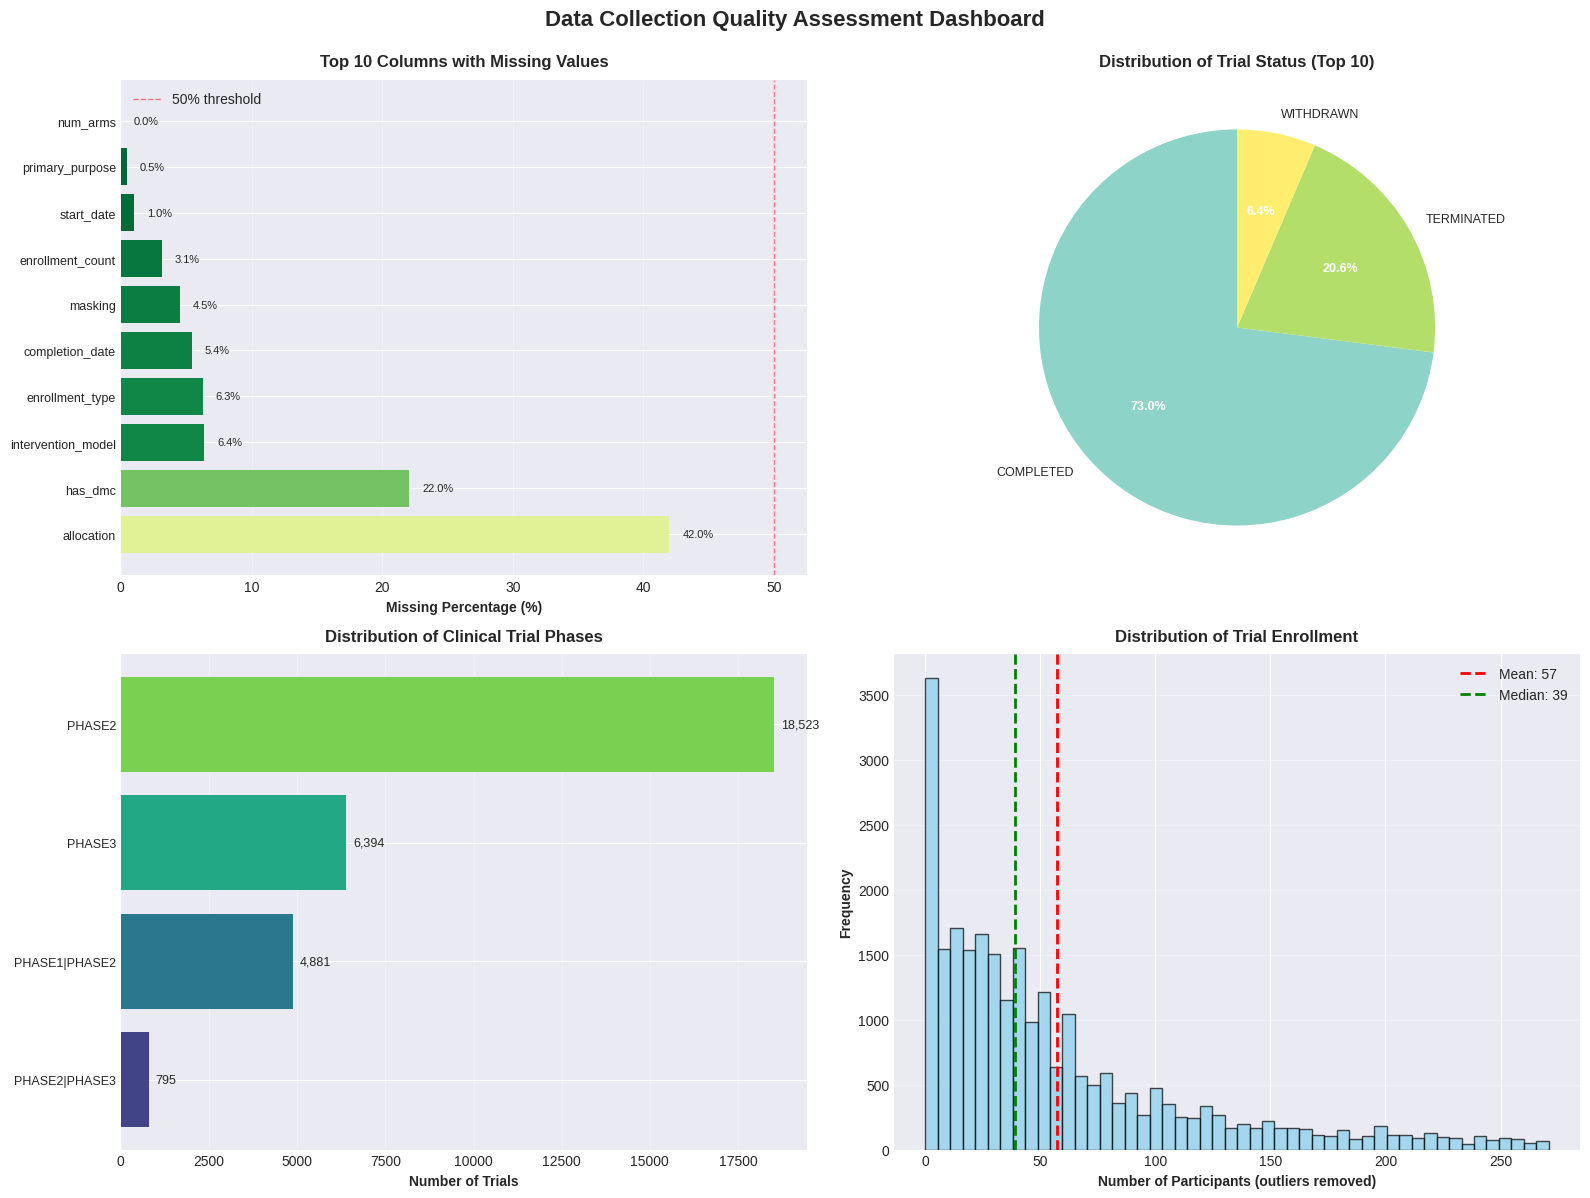

In [22]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Create a comprehensive visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Data Collection Quality Assessment Dashboard', fontsize=16, fontweight='bold', y=0.995)

# 1. Top 10 Missing Value Percentages (Top-left)
ax1 = axes[0, 0]
missing_pct = df.isna().mean().sort_values(ascending=False).head(10) * 100
colors = plt.cm.RdYlGn_r(missing_pct / 100)  # Color gradient from green (low) to red (high)

bars = ax1.barh(range(len(missing_pct)), missing_pct, color=colors)
ax1.set_yticks(range(len(missing_pct)))
ax1.set_yticklabels(missing_pct.index, fontsize=9)
ax1.set_xlabel('Missing Percentage (%)', fontweight='bold')
ax1.set_title('Top 10 Columns with Missing Values', fontweight='bold', pad=10)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, missing_pct)):
    ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

# 2. Trial Status Distribution (Top-right)
ax2 = axes[0, 1]
if 'overall_status' in df.columns:
    status_counts = df['overall_status'].value_counts().head(10)
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(status_counts)))
    
    wedges, texts, autotexts = ax2.pie(status_counts.values, 
                                         labels=status_counts.index, 
                                         autopct='%1.1f%%',
                                         colors=colors_pie,
                                         startangle=90,
                                         textprops={'fontsize': 9})
    ax2.set_title('Distribution of Trial Status (Top 10)', fontweight='bold', pad=10)
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
else:
    ax2.text(0.5, 0.5, 'Status data not available', ha='center', va='center')
    ax2.set_title('Distribution of Trial Status', fontweight='bold', pad=10)

# 3. Trial Phase Distribution (Bottom-left)
ax3 = axes[1, 0]
if 'phases' in df.columns:
    phase_counts = df['phases'].value_counts().sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(phase_counts)))
    
    bars = ax3.barh(range(len(phase_counts)), phase_counts.values, color=colors)
    ax3.set_yticks(range(len(phase_counts)))
    ax3.set_yticklabels(phase_counts.index, fontsize=9)
    ax3.set_xlabel('Number of Trials', fontweight='bold')
    ax3.set_title('Distribution of Clinical Trial Phases', fontweight='bold', pad=10)
    ax3.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, phase_counts.values)):
        ax3.text(val + max(phase_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Phase data not available', ha='center', va='center')
    ax3.set_title('Distribution of Clinical Trial Phases', fontweight='bold', pad=10)

# 4. Enrollment Distribution (Bottom-right)
ax4 = axes[1, 1]
if 'enrollment_count' in df.columns:
    enrollment_data = df['enrollment_count'].dropna()
    
    if len(enrollment_data) > 0:
        # Remove extreme outliers for better visualization
        Q1 = enrollment_data.quantile(0.25)
        Q3 = enrollment_data.quantile(0.75)
        IQR = Q3 - Q1
        filtered_enrollment = enrollment_data[(enrollment_data >= Q1 - 1.5*IQR) & 
                                               (enrollment_data <= Q3 + 1.5*IQR)]
        
        ax4.hist(filtered_enrollment, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        ax4.axvline(filtered_enrollment.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {filtered_enrollment.mean():.0f}')
        ax4.axvline(filtered_enrollment.median(), color='green', linestyle='--', 
                    linewidth=2, label=f'Median: {filtered_enrollment.median():.0f}')
        ax4.set_xlabel('Number of Participants (outliers removed)', fontweight='bold')
        ax4.set_ylabel('Frequency', fontweight='bold')
        ax4.set_title('Distribution of Trial Enrollment', fontweight='bold', pad=10)
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No enrollment data available', ha='center', va='center')
else:
    ax4.text(0.5, 0.5, 'Enrollment data not available', ha='center', va='center')
    ax4.set_title('Distribution of Trial Enrollment', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 7. Feature Catalog & Data Dictionary

In [23]:
print("="*80)
print("DATA DICTIONARY - KEY COLUMNS FOR CLINICAL TRIAL FAILURE PREDICTION")
print("="*80)

# Define column categories and their importance
categories = {
    'Identification': ['nct_id', 'org_study_id', 'brief_title', 'official_title'],
    'Trial Design': ['study_type', 'phases', 'allocation', 'intervention_model', 'masking', 
                     'primary_purpose'],
    'Status & Timeline': ['overall_status', 'start_date', 'completion_date', 
                          'primary_completion_date', 'last_update_posted_date'],
    'Participants': ['enrollment_count', 'enrollment_type', 'gender', 'minimum_age', 'maximum_age',
                     'healthy_volunteers'],
    'Intervention': ['intervention_types', 'intervention_names', 'intervention_description'],
    'Sponsor & Location': ['lead_sponsor_name', 'lead_sponsor_class', 'location_countries'],
    'Outcomes': ['primary_outcome_measure', 'secondary_outcome_measure', 'has_results']
}

# Display available columns by category
for category, cols in categories.items():
    print(f"\n{category.upper()}")
    print("-" * 80)
    available_cols = [col for col in cols if col in df.columns]
    missing_cols = [col for col in cols if col not in df.columns]
    
    if available_cols:
        print(f"Available columns ({len(available_cols)}):")
        for col in available_cols:
            non_null = df[col].notna().sum()
            null_pct = df[col].isna().mean() * 100
            dtype = df[col].dtype
            nunique = df[col].nunique() if df[col].dtype == 'object' or df[col].dtype.name == 'category' else 'N/A'
            
            indicator = "🟢" if null_pct < 20 else "🟡" if null_pct < 50 else "🔴"
            print(f"  {indicator} {col:30s} | Type: {str(dtype):10s} | Non-null: {non_null:6,} ({100-null_pct:5.1f}%) | Unique: {nunique}")
    
    if missing_cols:
        print(f"Missing columns ({len(missing_cols)}): {', '.join(missing_cols)}")

print("\n" + "="*80)
print("LEGEND")
print("="*80)
print("Good quality (< 20% missing)")
print("Moderate quality (20-50% missing)")
print("Poor quality (> 50% missing)")
print("\nData Dictionary generated successfully!")

DATA DICTIONARY - KEY COLUMNS FOR CLINICAL TRIAL FAILURE PREDICTION

IDENTIFICATION
--------------------------------------------------------------------------------
Available columns (2):
  🟢 nct_id                         | Type: object     | Non-null: 30,593 (100.0%) | Unique: 30593
  🟢 brief_title                    | Type: object     | Non-null: 30,593 (100.0%) | Unique: 30490
Missing columns (2): org_study_id, official_title

TRIAL DESIGN
--------------------------------------------------------------------------------
Available columns (6):
  🟢 study_type                     | Type: object     | Non-null: 30,593 (100.0%) | Unique: 1
  🟢 phases                         | Type: object     | Non-null: 30,593 (100.0%) | Unique: 4
  🟡 allocation                     | Type: object     | Non-null: 17,750 ( 58.0%) | Unique: 2
  🟢 intervention_model             | Type: object     | Non-null: 28,646 ( 93.6%) | Unique: 5
  🟢 masking                        | Type: object     | Non-null: 29,206

##  8. Summary collection:

In [24]:
print("\n" + "="*80)
print("FINAL COLLECTION SUMMARY")
print("="*80)

# Data volume
print(f"\nDATA VOLUME:")
print(f"  Total Trials:       {len(df):,}")
print(f"  Total Features:     {len(df.columns):,}")
print(f"  Total Data Points:  {df.size:,}")
print(f"  Memory Size:        {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data quality
print(f"\nQUALITY METRICS:")
print(f"  Overall Score:      {overall_score:.1f}%")
print(f"  Completeness:       {completeness_score:.1f}%")
print(f"  Uniqueness:         {uniqueness_score:.1f}%")
print(f"  Validity:           {validity_score:.1f}%")
print(f"  Quality Rating:     {quality_rating}")

# Target distribution
if 'overall_status' in df.columns:
    completed = (df['overall_status'] == 'COMPLETED').sum()
    terminated = (df['overall_status'] == 'TERMINATED').sum()
    withdrawn = (df['overall_status'] == 'WITHDRAWN').sum()
    
    success_count = completed
    failure_count = terminated + withdrawn
    total_labeled = success_count + failure_count
    
    print(f"\nTARGET DISTRIBUTION (for prediction):")
    print(f"  Success (COMPLETED):        {success_count:,} ({success_count/total_labeled*100:.1f}%)")
    print(f"  Failure (TERM/WITHDRAWN):   {failure_count:,} ({failure_count/total_labeled*100:.1f}%)")
    print(f"  Total Labeled:              {total_labeled:,}")
    
    # Class balance check
    imbalance_ratio = max(success_count, failure_count) / min(success_count, failure_count) if min(success_count, failure_count) > 0 else float('inf')
    print(f"  Class Imbalance Ratio:      {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 3:
        print(f"   Warning: Significant class imbalance detected")
        print(f"     Consider: SMOTE, class weights, or stratified sampling")
    else:
        print(f"  Class distribution is relatively balanced")

# Files generated
print(f"\nOUTPUT FILES:")
print(f"  Raw JSONL:          {raw_path}")
print(f"  Processed CSV:      {csv_path}")
print(f"  Metadata:           {meta_path}")
print(f"  Collection Log:     {log_path}")

print("\n" + "="*80)
print("DATA COLLECTION PIPELINE: COMPLETED SUCCESSFULLY")
print("="*80)


FINAL COLLECTION SUMMARY

DATA VOLUME:
  Total Trials:       30,593
  Total Features:     23
  Total Data Points:  703,639
  Memory Size:        36.01 MB

QUALITY METRICS:
  Overall Score:      98.6%
  Completeness:       96.0%
  Uniqueness:         100.0%
  Validity:           100.0%
  Quality Rating:     EXCELLENT

TARGET DISTRIBUTION (for prediction):
  Success (COMPLETED):        22,329 (73.0%)
  Failure (TERM/WITHDRAWN):   8,264 (27.0%)
  Total Labeled:              30,593
  Class Imbalance Ratio:      2.70:1
  Class distribution is relatively balanced

OUTPUT FILES:
  Raw JSONL:          /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
  Processed CSV:      /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/ctgov_flat.csv
  Metadata:           None
  Collection Log:     /home/lang-phu-quy/Documents/Introduction to Data Science/Fi

### 8.1 Nhận xét:

Đã thu thập thành công bộ dữ liệu thử nghiệm lâm sàng về ung thư từ ClinicalTrials.gov, đủ làm nền tảng xây mô hình dự đoán nguy cơ thất bại.

**Hoàn thành:**

- Kết nối API ClinicalTrials.gov thành công

- Thu thập các trial liên quan đến ung thư

- Làm phẳng JSON phức tạp → CSV để phân tích

- Đánh giá chất lượng & độ đầy đủ dữ liệu

- Tạo thống kê mô tả và trực quan hóa

- Ghi nhận đầy đủ đặc trưng và metadata

### 8.2 Tổng quan bộ dữ liệu

Bộ dữ liệu gồm:

- Tổng số dòng: theo df.shape

- Số trial duy nhất: theo phân tích NCT ID

- Độ đầy đủ dữ liệu: theo báo cáo missing/quality

- Đặc trưng chính:Trial status, phase, enrollment, interventions, sponsors, locations, and outcomes

### 8.3 Nhận xét về chất lượng dữ liệu

Điểm mạnh:

- NCT ID duy nhất giúp đảm bảo toàn vẹn

- Nhiều biến phân loại hữu ích (thiết kế, trạng thái)

- Có thông tin thời gian cho phân tích tiến trình

- Dữ liệu nhà tài trợ và địa điểm tương đối đầy đủ

Vấn đề cần xử lý khi tiền xử lý:

- Tỷ lệ thiếu khác nhau giữa các cột

- Một số cột có quá nhiều giá trị (cần feature engineering)

- Trường ngày cần parse và tách đặc trưng

Trạng thái: Hoàn tất thu thập dữ liệu — sẵn sàng tiền xử lý.